<a href="https://colab.research.google.com/github/majorquev/DBDC_202604_Programacion_en_R_para_ciencia_de_datos/blob/main/Clases/Clase4/02_Visualizaciones_ggplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 3: Introducción a GGplot2

**Autor:** Miguel Jorquera Viguera<br>
**E-mail:** majorquev@gmail.com<br>
**Ayudante:** Rodrigo Morales<br>
**E-mail ayudante:** rumorale1@gmail.com

Ggplot es una librería basada en la gramática de gráficos, creadapor Wilkinson (2015). Básicamente la gramática de gráficos nos dice que un gráfico estadístico corresponde a un mapeo entre la data hacia atributos estéticos (como el color, forma o tamaño) de objetos geométricos (como puntos, líneas o barras).

## Referencias útiles

 * https://ggplot2.tidyverse.org/reference/index.html
 * https://r4ds.had.co.nz/data-visualisation.html
 * https://www.rdocumentation.org/packages/ggplot2/versions/3.3.0


## Cheatsheets
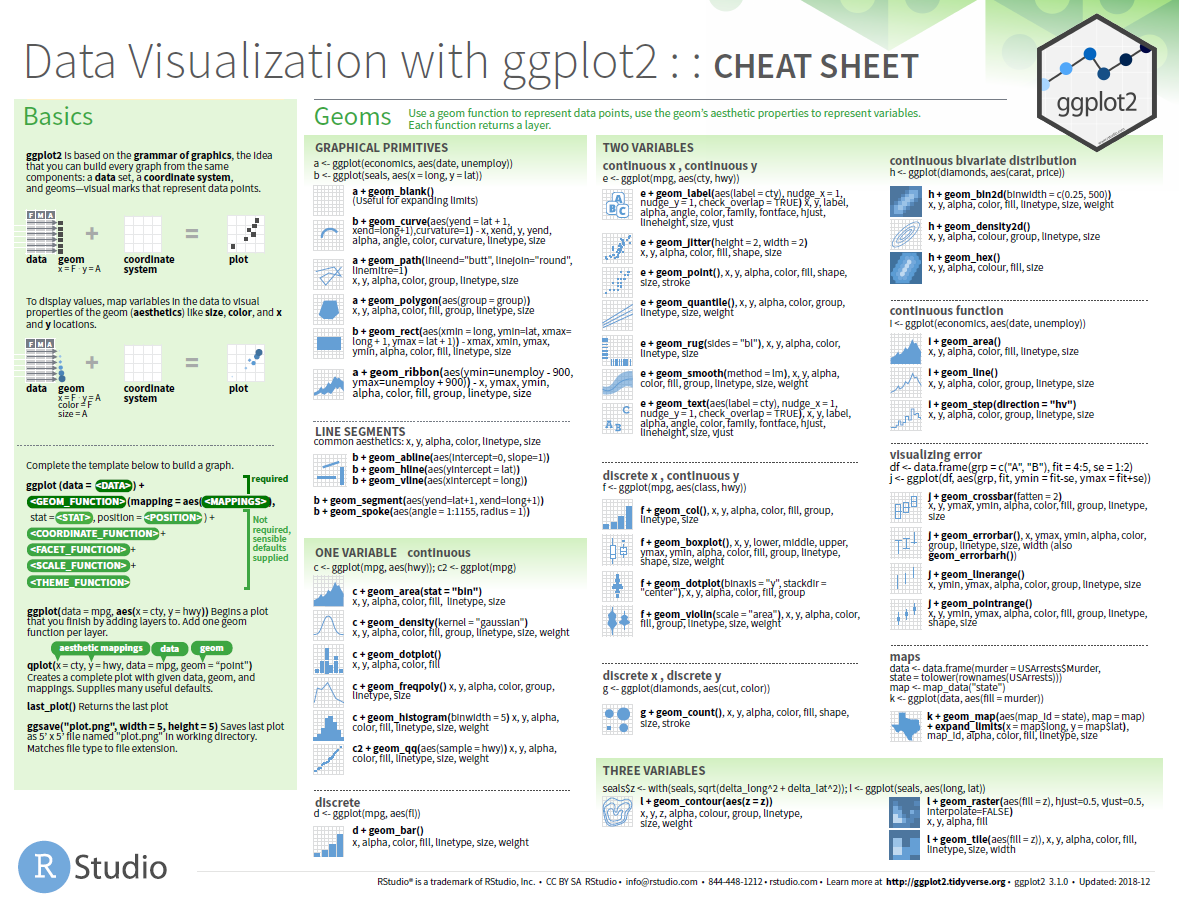


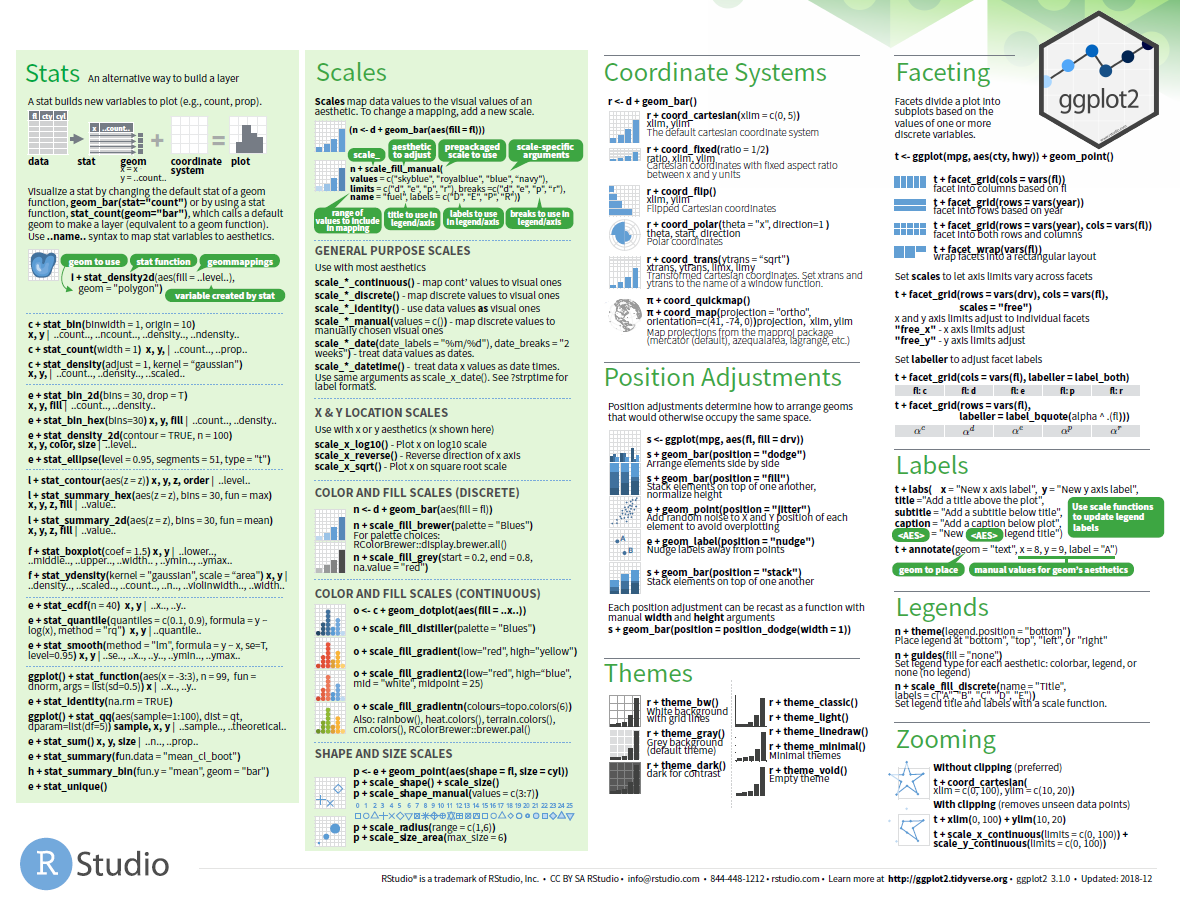


In [1]:
# Cargamos la librería
library(ggplot2) # install.packages("ggplot2")
# Otras librerías que pueden ser de interés: leaflet, iplots, highcharter * ,ggmap, visNetwork**

Para entender el funcionamiento de esta grámatica comencemos con un ejemplo analizando la data mpg:

In [2]:
# "+" es mas o menos lo mismo en ggplot que %>% de dplyr
data(mpg)
mpg

manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact
audi,a4,3.1,2008,6,auto(av),f,18,27,p,compact
audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
audi,a4 quattro,1.8,1999,4,auto(l5),4,16,25,p,compact


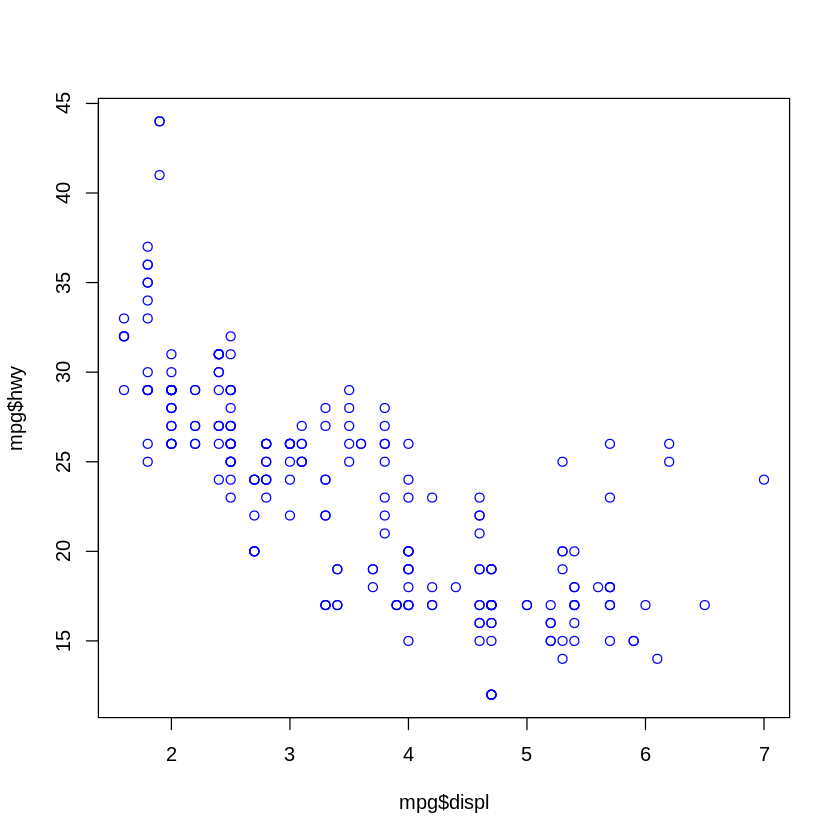

In [3]:
plot(mpg$displ, mpg$hwy, col = "blue") # Esto no es ggplot

In [4]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




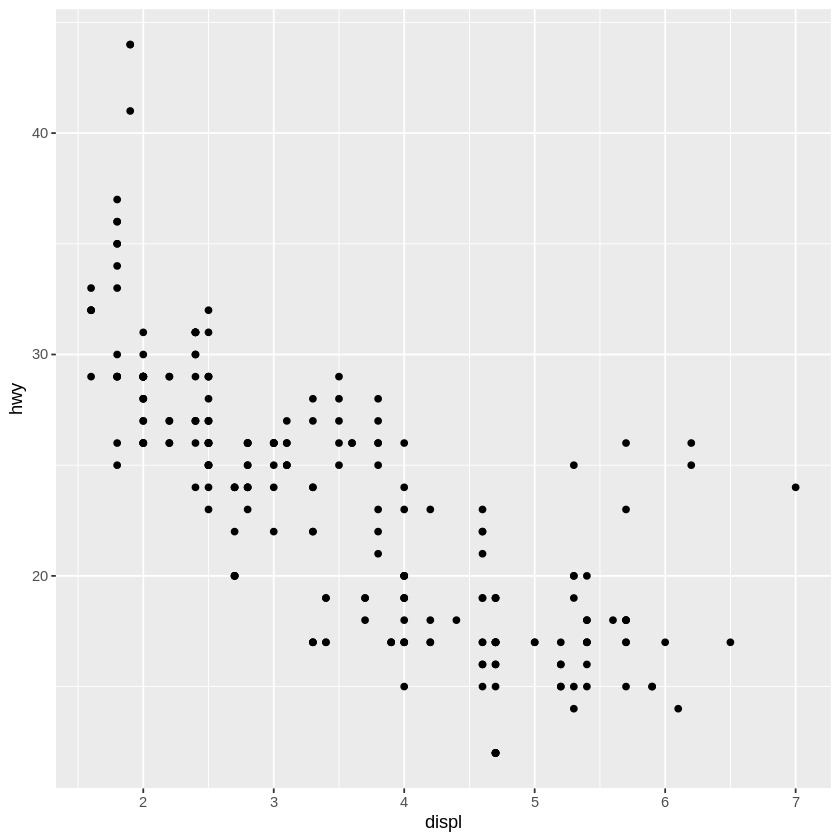

In [5]:
mpg %>%
    ggplot() + # Indicamos el origen de los datos que buscamos visualizar
    aes(x = displ, y = hwy) + # capa "estética" : aesthetical mapping (indicamos qué variables queremos visualizar)
    geom_point() # capa geométrica, se indica "cómo" queremos visualizar las variables indicadas en el aesthetical mapping

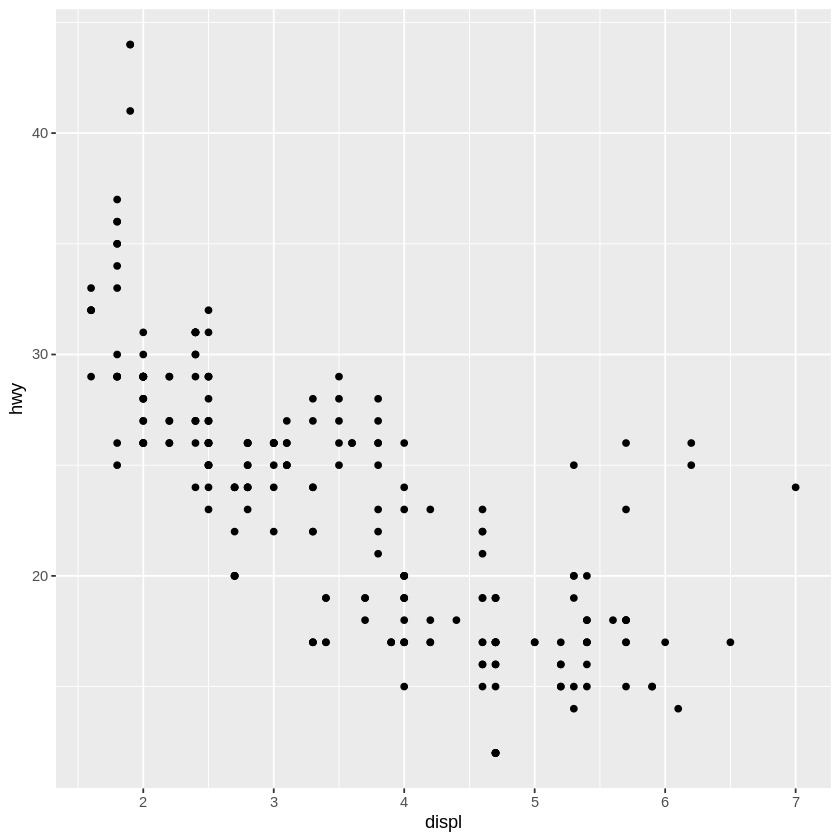

In [6]:
# tambien podemos generar el gráfico de la siguiente manera (aes( coo parametro mapping))
ggplot(data = mpg, mapping = aes(x = displ, y = hwy)) +
    geom_point()

# I. Color, tamaño, forma y otros atributos estéticos

## I.1. Color
El color está dado por la variable categórica class (notar que es lo mismo si incluimos el parámetro color, colour o col. ggplot automáticamente entiende lo que queremos :) )

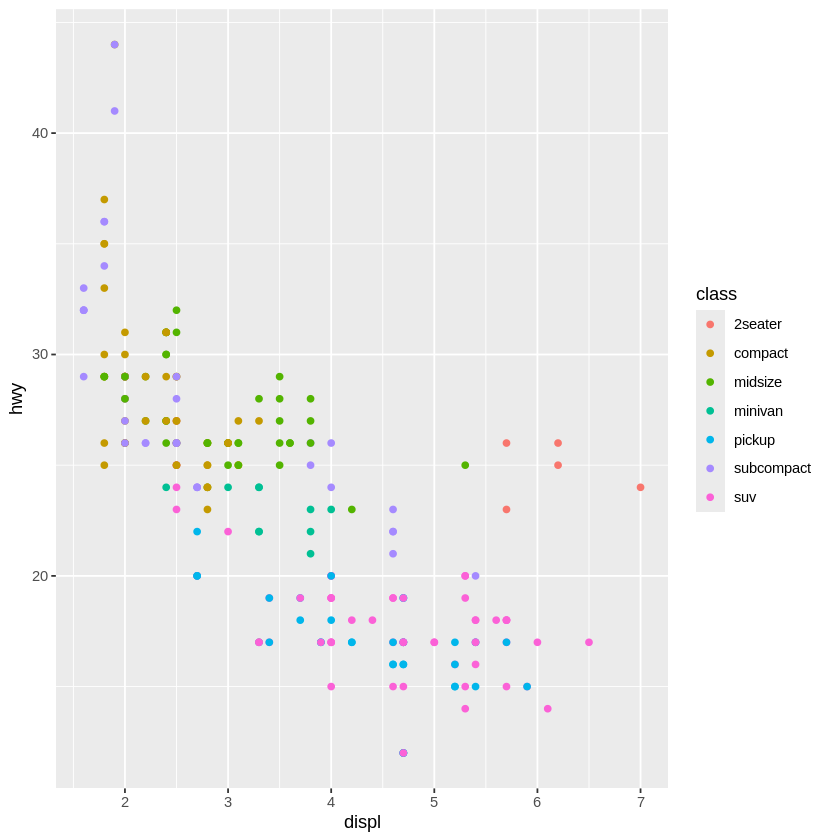

In [7]:
## Color por "class" dentro de aes
mpg %>%
    ggplot() +
    aes(x = displ, y = hwy, color = class) +
    geom_point()

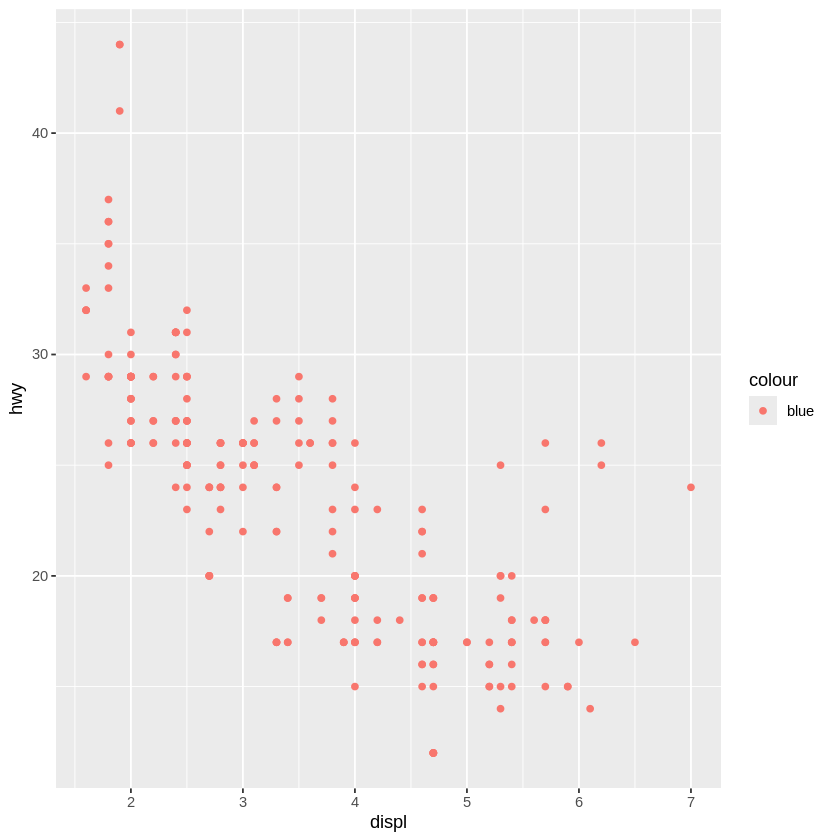

In [8]:
# y si queremos color azul?
mpg %>%
    ggplot() +
    aes(x = displ, y = hwy, color = "blue") + # Qué
    geom_point()


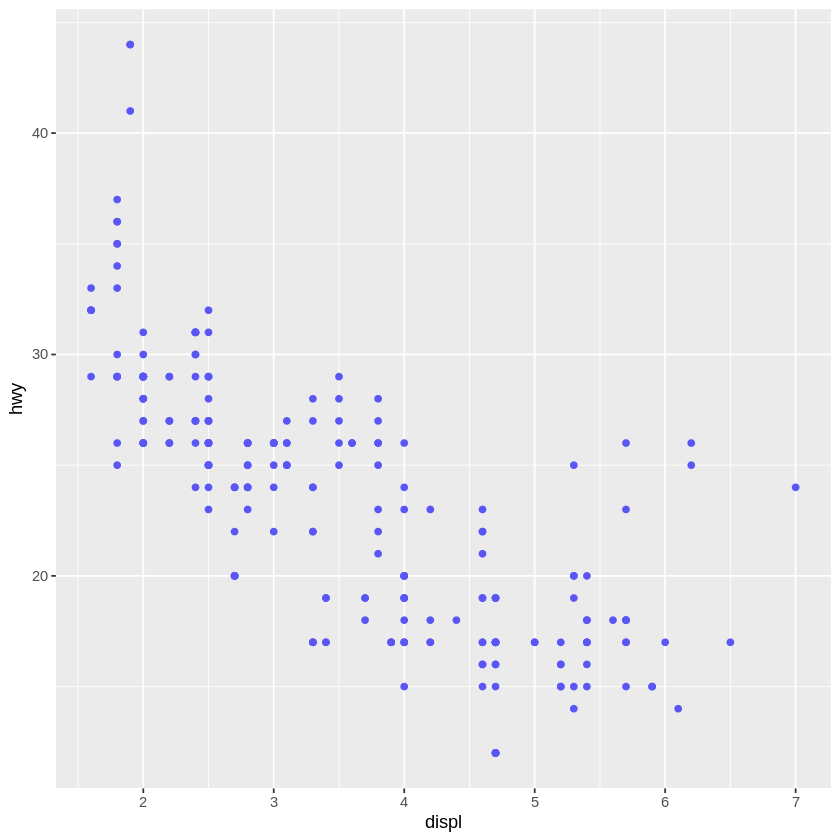

In [9]:
mpg %>%
    ggplot() +
    aes(x = displ, y = hwy) +
    geom_point(color = "#5a56f5")

In [10]:
head(mpg)

manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact


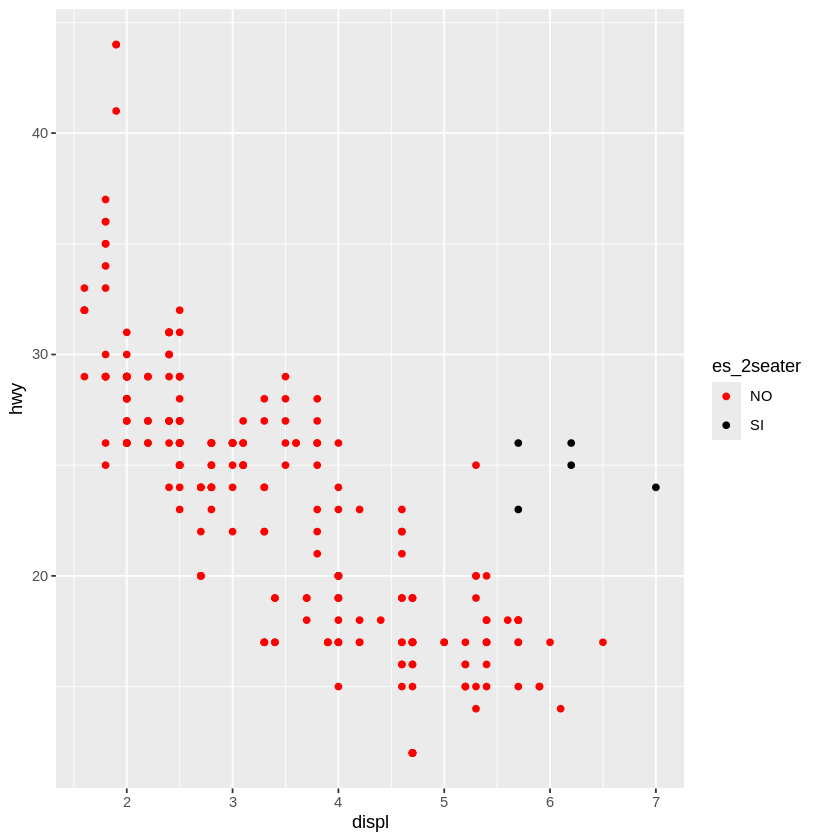

In [11]:
# Que pasa si queremos colorear en negro solo los de class "2seater"
mpg %>%
  # mutate(es_2seater = class == "2seater") #Op1 como booleano
  mutate(es_2seater = ifelse(class == "2seater", "SI", "NO")) %>%
  ggplot() +
  aes(x = displ, y = hwy, color = es_2seater) +
  geom_point() +
  scale_color_manual(values = c("red", "black"))


In [12]:
head(mpg)

manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact


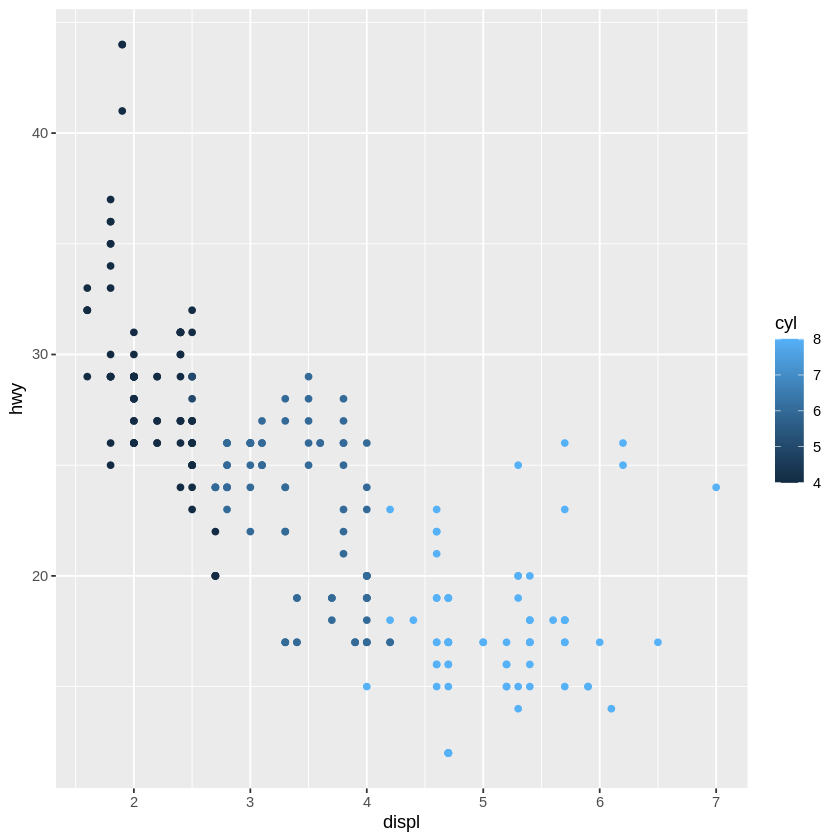

In [13]:
# que sucede si el color no es una variable discreta (categórica)
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, color = cyl) +
  geom_point()


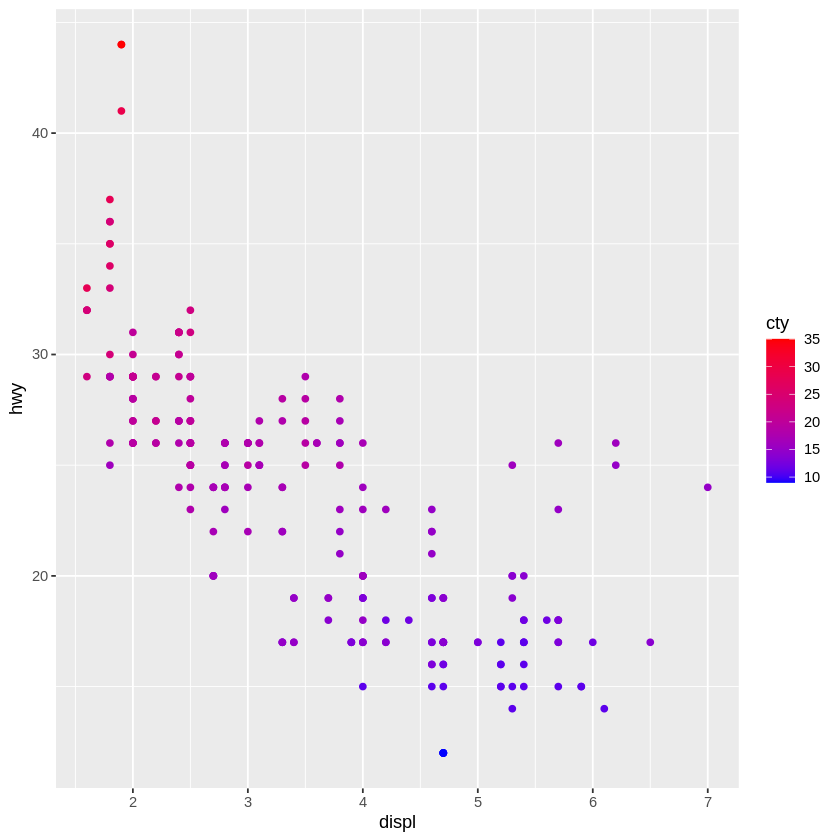

In [14]:
# Modificar la escala de colores y dar la impresión de "intensidad"
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, color = cty) +
  geom_point() +
  scale_color_continuous(low = "blue", high = "red")

## I.2. Forma

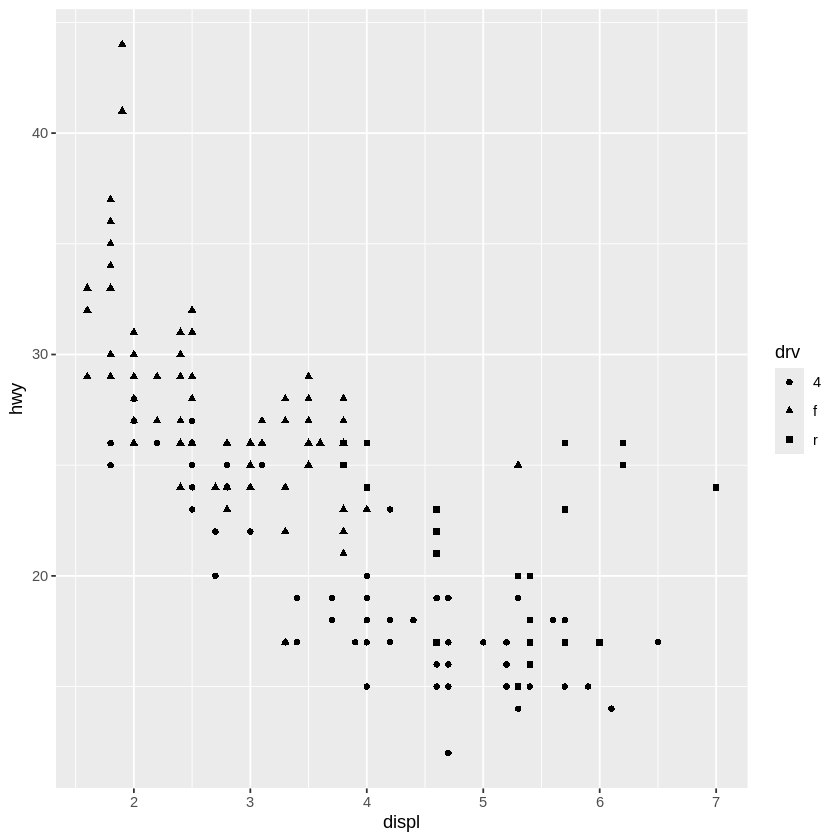

In [15]:
## Forma (shape) según "drv"
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, shape = drv) +
  geom_point()

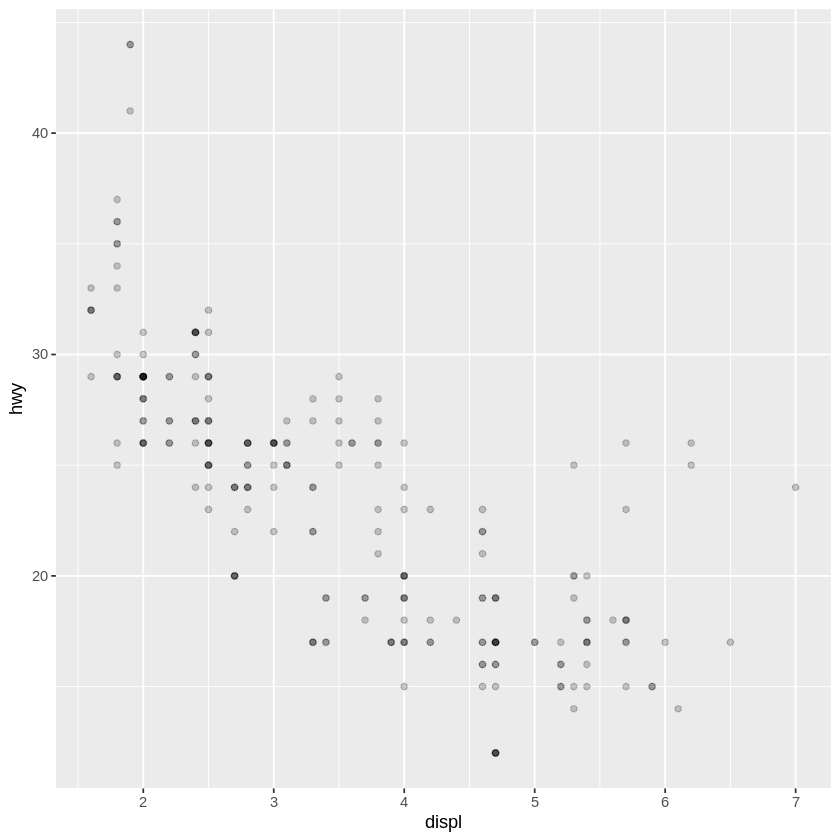

In [16]:
# El parámetro alpha permite regular la intensidad el color en función de la densidad de los puntos.
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy) +
  geom_point(alpha = 0.2)

## I.3. Forma y color

In [17]:
## Forma y color (color = class, shape = drv)


## I.4. Tamaño

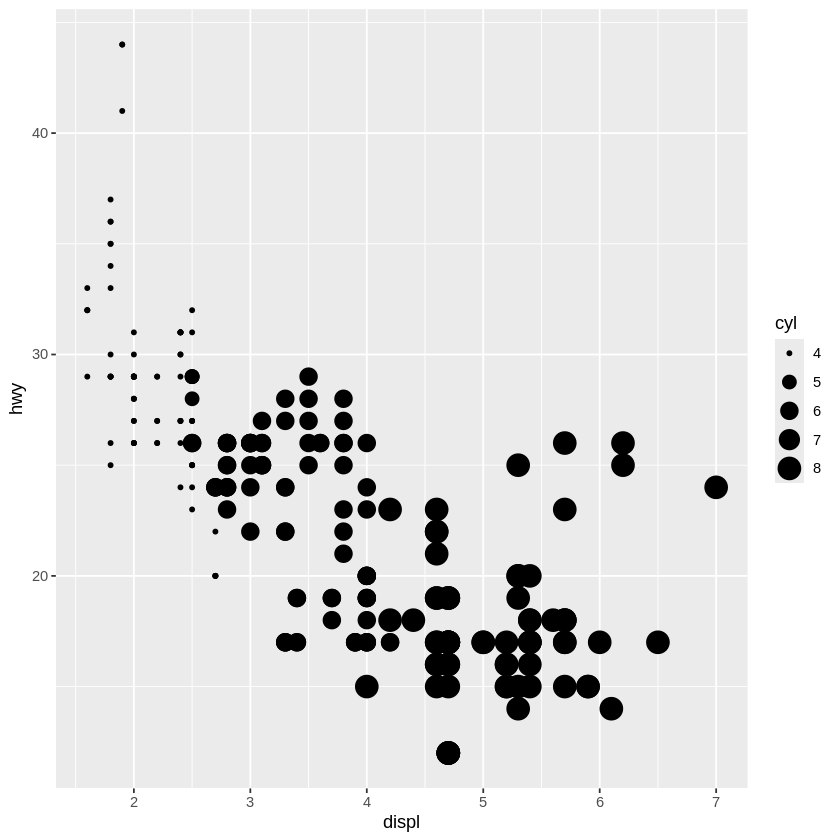

In [18]:
## Tamaño (size) según "cyl"
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, size = cyl) +
  geom_point()

Warning message:
“Using size for a discrete variable is not advised.”


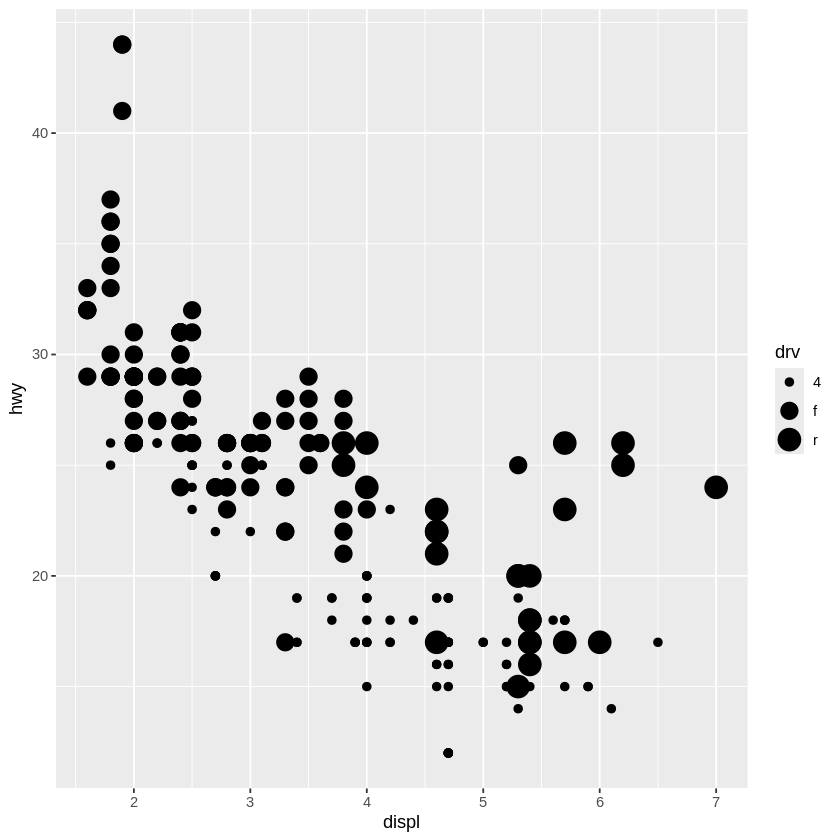

In [19]:
# size = drv? nota: no tiene sentido dar el tamaño segú nuna variable categórica (R internamente la ordena alfabéticamente y luego asigna el valor del tamañao)
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, size = drv) +
  geom_point()

# II. Facetas

En inglés Facetting, es una manera de dividir la data disponible según variables categóricas y mostrar el mismo gráfico por cada categoría en una misma imagen.

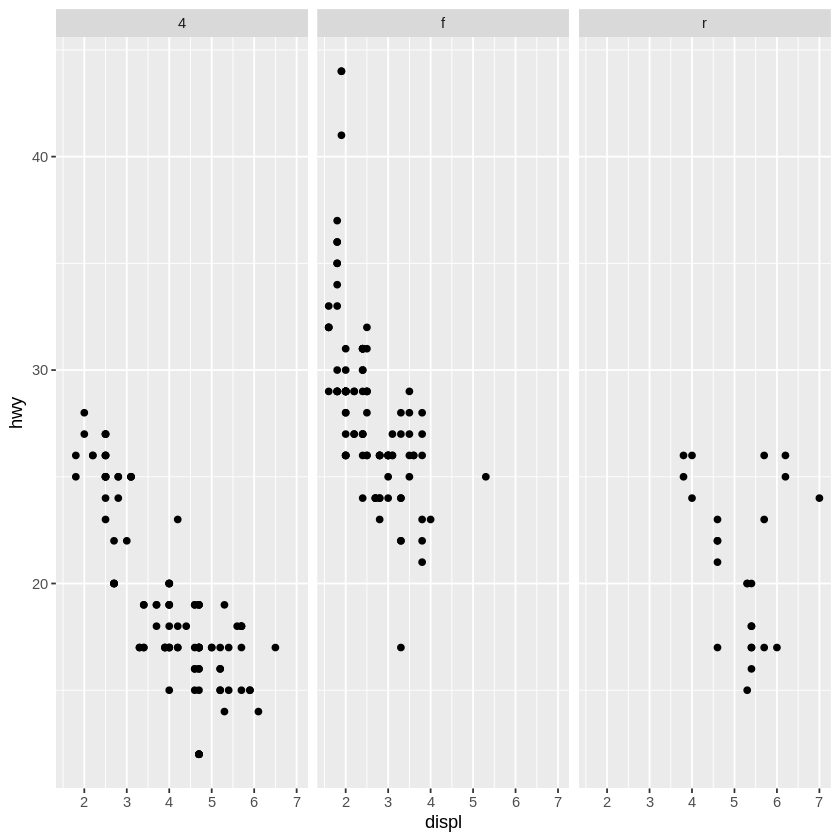

In [20]:
# Apertura por drv # small multiples
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy) +
  geom_point() +
  facet_wrap(~ drv)




Grafique otras relaciones entre la eficiencia (hwy o cty), tamaño del motor (displ) por cada  número de cilindros (cyl). ¿Qué se observa?

In [21]:
# Por ejemplo, x=displ,y=hwy , aperturado por número de cilindros


# III. Capas geométricas: prefijo geom_

Hasta aquí hemos utilizado sólo una de las diversas maneras de mostrar (geométricamente hablando) la relación entre las variables hasta aquí descritas.
En ggplot existe una gran variedad de funciones "geom_", sólo veremos algunas de ellas, aunque en la documentación oficial se describen todas las opciones disponibles https://ggplot2.tidyverse.org/index.html

## III.1 geom_point()

La fución geom_point() se encarga de visualizar las variables definidas en aes() como un gráfico de dispersión.

## III.2 geom_smooth()
Con esta función podemos añadir una curva de tendencia a nuestros datos


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


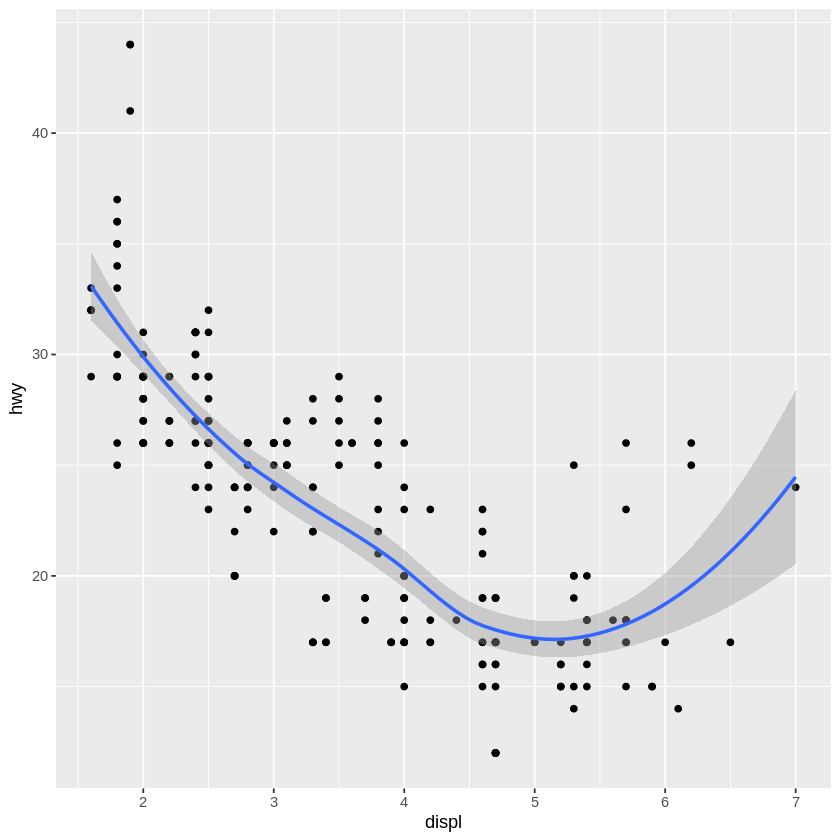

In [22]:
#geom_smooth()

mpg %>%
  ggplot() +
  aes(x = displ, y = hwy) +
  geom_point() +
  geom_smooth()


In [23]:
?geom_smooth

¿Cómo podemos graficar las curvas de tendencia para cada tipo de tracción (drv)?

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


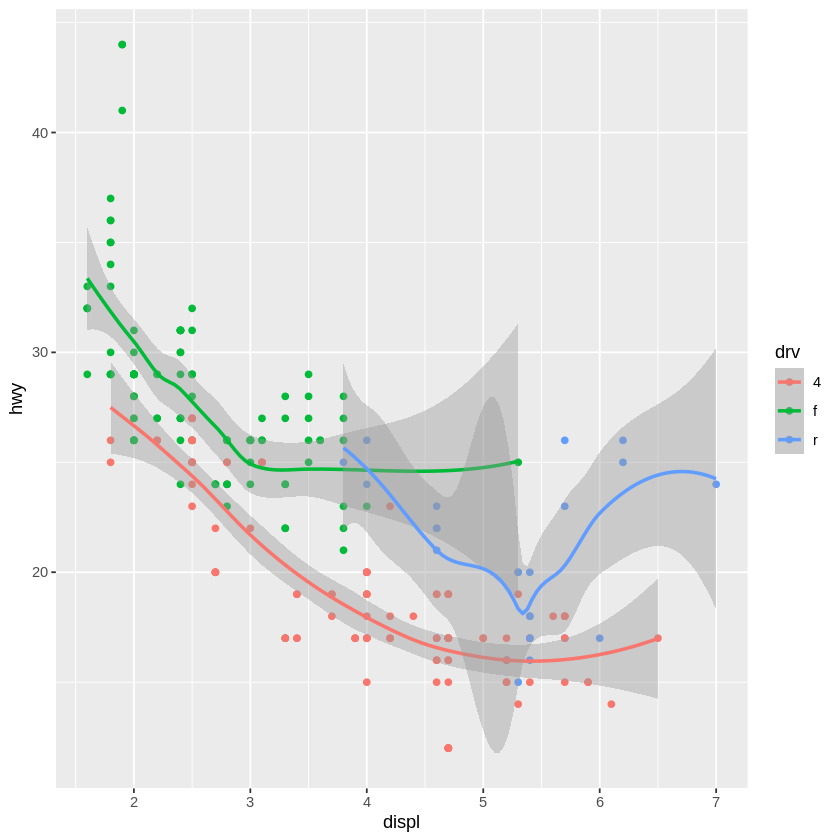

In [24]:
# por color
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, color = drv) +
  geom_point() +
  geom_smooth()

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


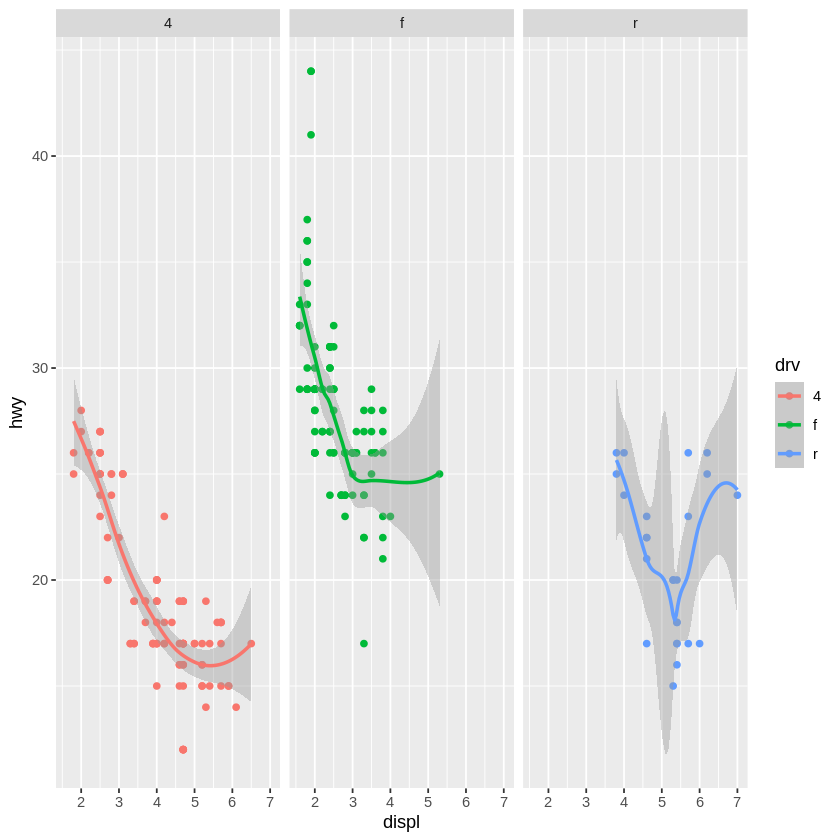

In [25]:
# y usando facet_wrap
mpg %>%
  ggplot() +
  aes(x = displ, y = hwy, col = drv) +
  geom_point() +
  facet_wrap(~ drv) +
  geom_smooth()

## III.3 geom_boxplot() y geom_jitter()
 Podemos variar la forma del gráfico modificando la capa geométrica con las funciones geom_
 Por ejemplo, hace un rato visualizamos la relación entre hwy y drv. Para este tipo de relaciones es más informativo un gráfico de cajas.

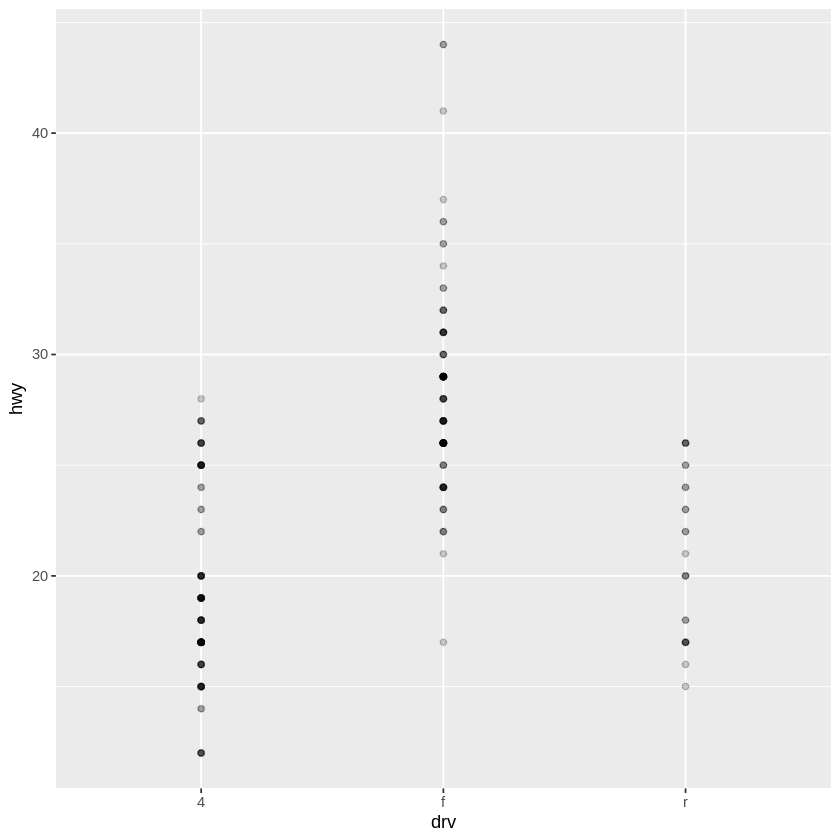

In [26]:
mpg %>%
  ggplot() +
  aes(x = drv, y = hwy) +
  geom_point(alpha = 0.2)

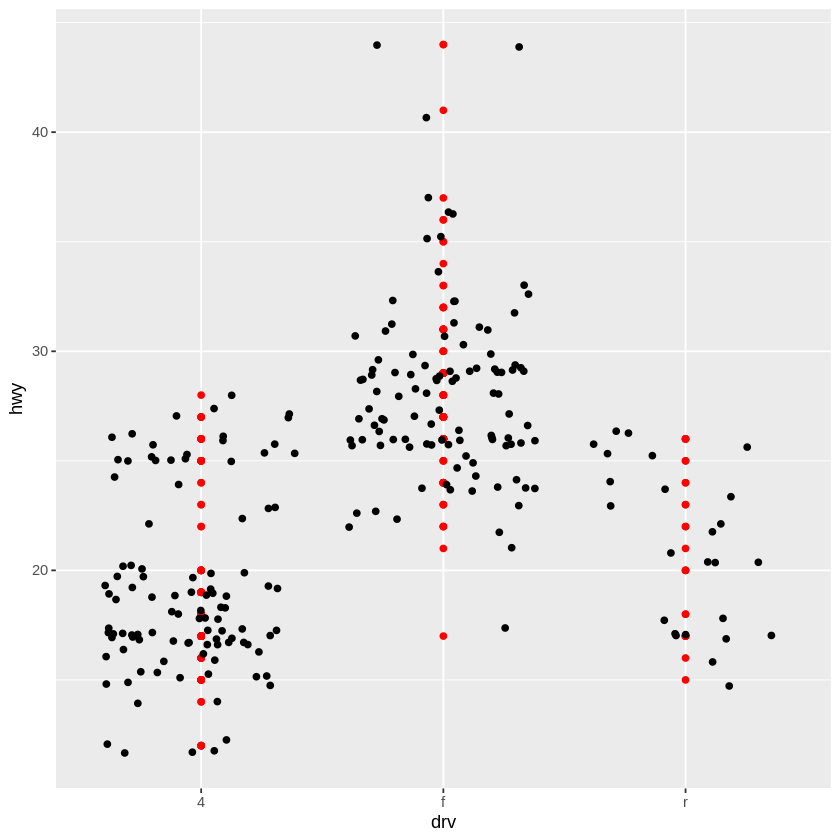

In [27]:
# Geom_jitter

mpg %>%
  ggplot() +
  aes(x = drv, y = hwy) +
  geom_point(col = "red") +
  geom_jitter()

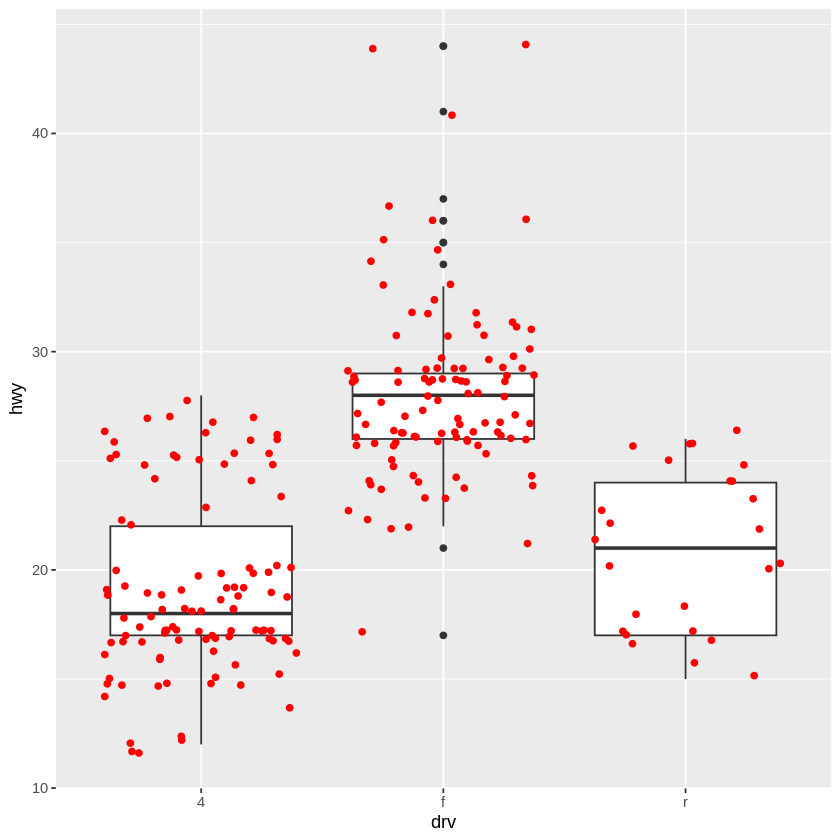

In [28]:
# Boxplot (gráficos de cajas)
mpg %>%
  ggplot() +
  aes(x = drv, y = hwy) +
  geom_boxplot() +
  geom_jitter(color = "red")

## III.4 geom_histogram() y  geom_freqpoly()

Con estas funciones es posible graficar histogramas y la frecuencia absoluta a través de una curva poligonal

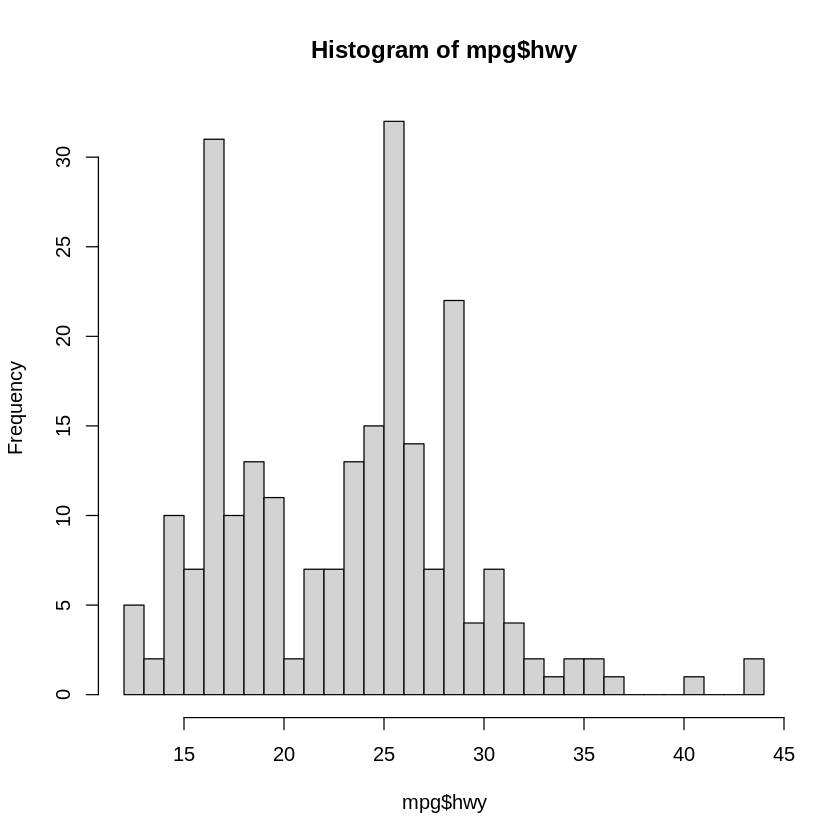

In [29]:
# Con base
hist(mpg$hwy,breaks = 30)

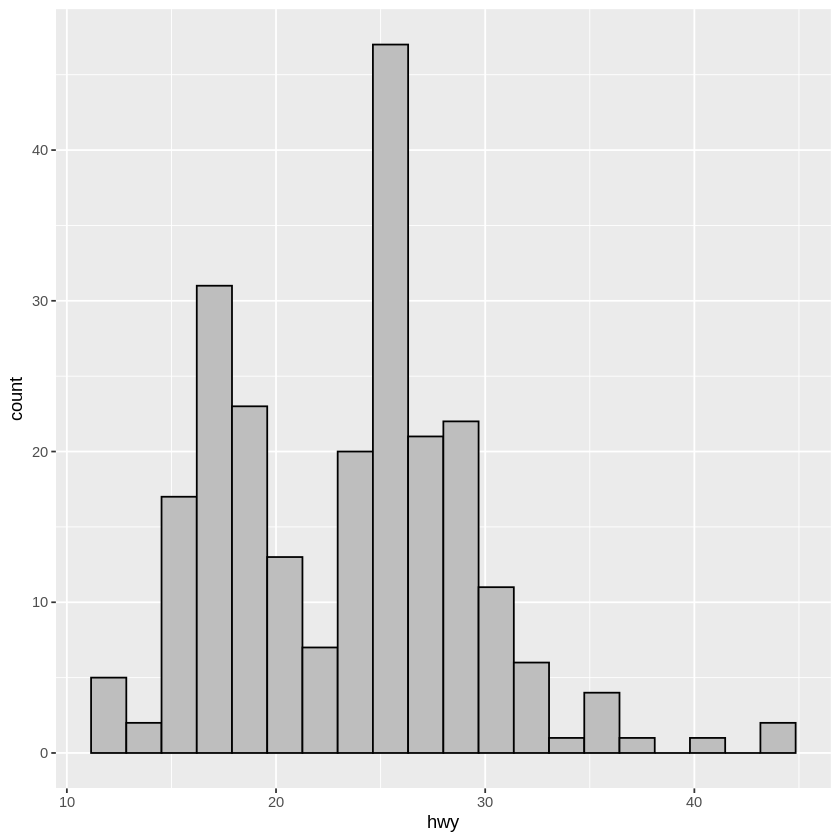

In [30]:
## histograma . Parámetro bins =30 en geom_histogram()
mpg %>%
  ggplot() +
  aes(x = hwy) +
  geom_histogram(color = "black", fill = "gray",bins = 20)


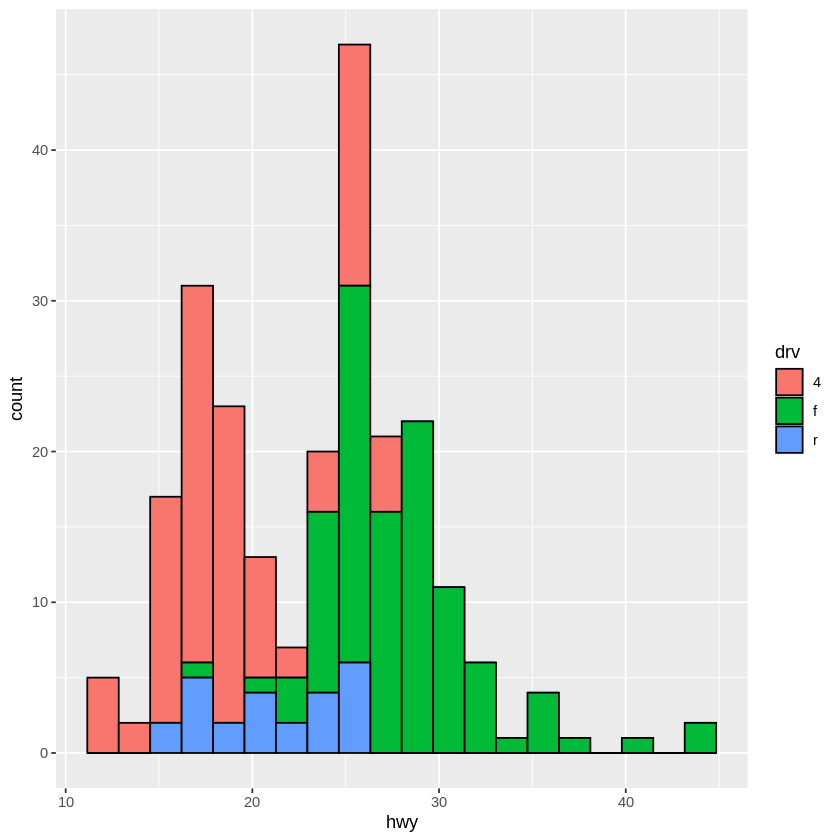

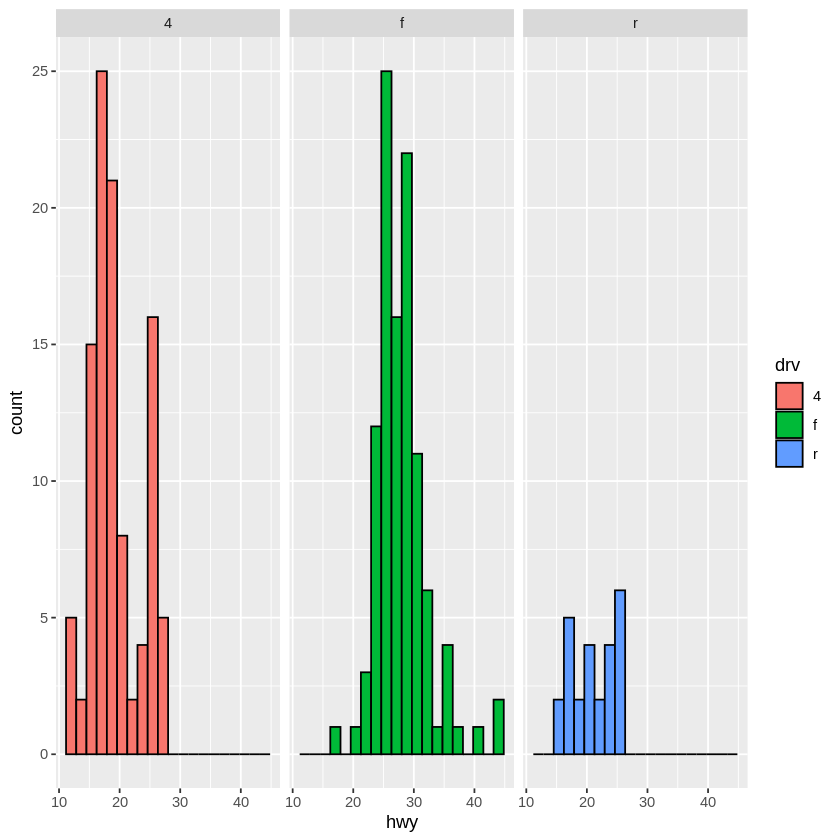

In [31]:
# podemos aperturar por drv (en color  y fill)
mpg %>%
  ggplot() +
  aes(x = hwy,  fill = drv) +
  geom_histogram(bins = 20, color = "black")

#usando facet_wrap

mpg %>%
  ggplot() +
  aes(x = hwy,  fill = drv) +
  geom_histogram(bins = 20, color = "black") +
  facet_wrap(~drv)

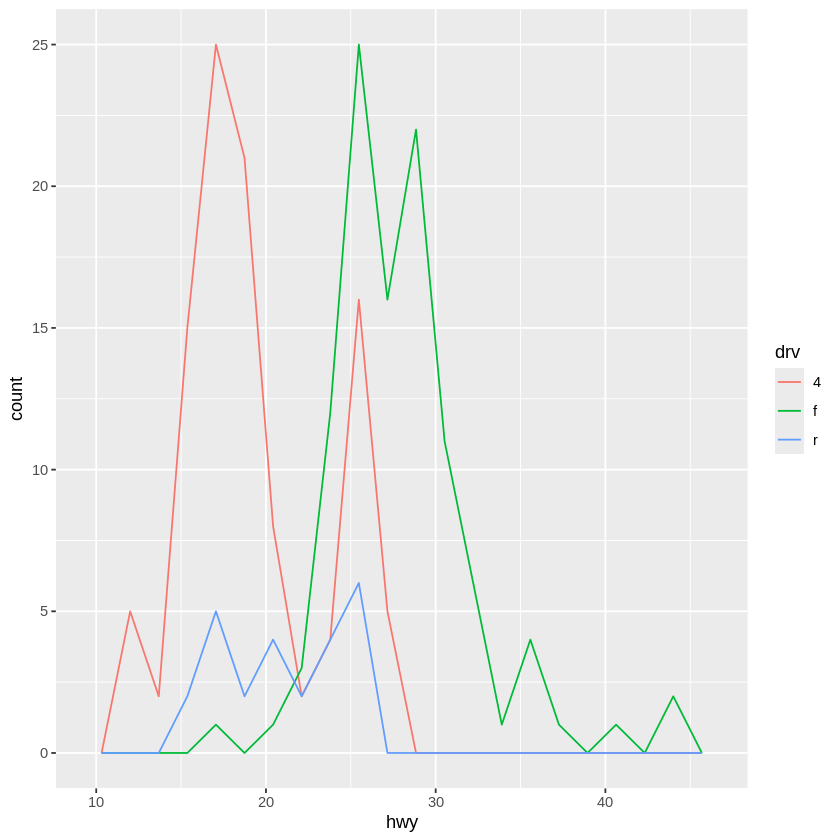

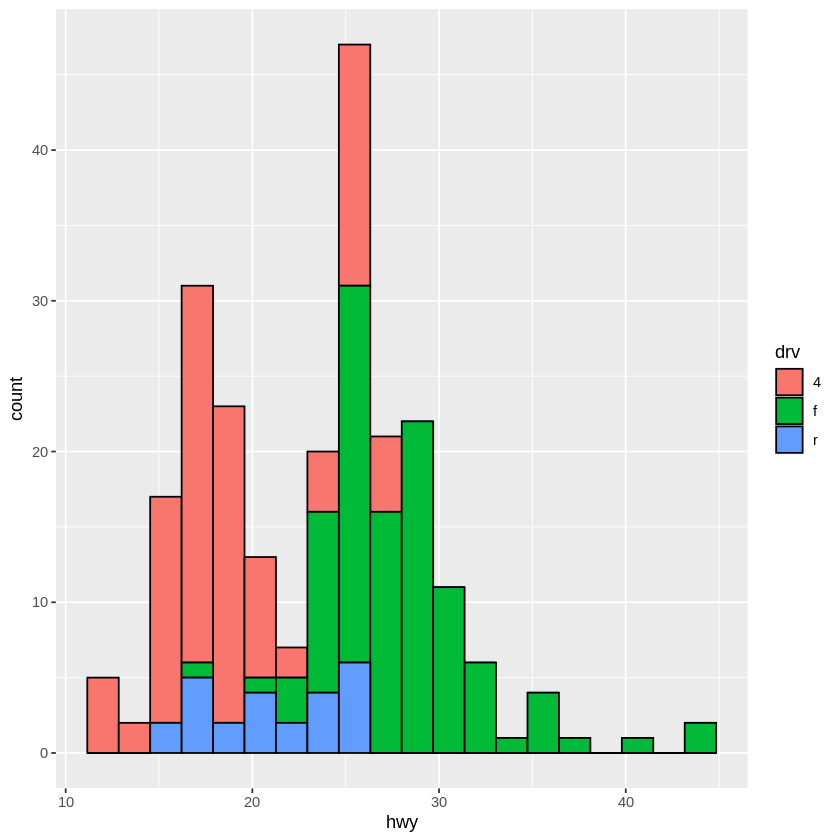

In [32]:
## polígono de frecuencias # geom_freqpoly

mpg %>%
  ggplot() +
  aes(x = hwy,  color = drv) +
  geom_freqpoly(bins = 20)
###

mpg %>%
  ggplot() +
  aes(x = hwy,  fill = drv) +
  geom_histogram(bins = 20, color = "black")

## III.4 geom_line()

Podemos generar gráficos de linea, por ejemplo de series temporales.










In [33]:
library(dplyr)
library(httr)
library(jsonlite)
library(ggplot2)

url_base <-"https://mindicador.cl"

consulta <- GET(url_base,path = "/api/dolar/2025")
consulta



Response [https://mindicador.cl/api/dolar/2025]
  Date: 2026-05-26 22:34
  Status: 200
  Content-Type: application/json; charset=utf-8
  Size: 13 kB


In [34]:
text <- content(consulta, as = "text")
content <- fromJSON(text)
class(content)

[1] "list"

In [35]:
str(content)


List of 6
 $ version      : chr "1.7.0"
 $ autor        : chr "mindicador.cl"
 $ codigo       : chr "dolar"
 $ nombre       : chr "Dólar observado"
 $ unidad_medida: chr "Pesos"
 $ serie        :'data.frame':	248 obs. of  2 variables:
  ..$ fecha: chr [1:248] "2025-12-30T03:00:00.000Z" "2025-12-29T03:00:00.000Z" "2025-12-26T03:00:00.000Z" "2025-12-24T03:00:00.000Z" ...
  ..$ valor: num [1:248] 911 905 905 906 908 ...


In [36]:
content$serie

,fecha,valor
,<chr>,<dbl>
1,2025-12-30T03:00:00.000Z,911.18
2,2025-12-29T03:00:00.000Z,904.54
3,2025-12-26T03:00:00.000Z,905.04
4,2025-12-24T03:00:00.000Z,906.44
5,2025-12-23T03:00:00.000Z,908.40
6,2025-12-22T03:00:00.000Z,909.90
7,2025-12-19T03:00:00.000Z,914.99
8,2025-12-18T03:00:00.000Z,917.45
9,2025-12-17T03:00:00.000Z,913.74


In [37]:
dolar_2025 <- content$serie

In [38]:
head(dolar_2025)

,fecha,valor
,<chr>,<dbl>
1,2025-12-30T03:00:00.000Z,911.18
2,2025-12-29T03:00:00.000Z,904.54
3,2025-12-26T03:00:00.000Z,905.04
4,2025-12-24T03:00:00.000Z,906.44
5,2025-12-23T03:00:00.000Z,908.40
6,2025-12-22T03:00:00.000Z,909.90


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


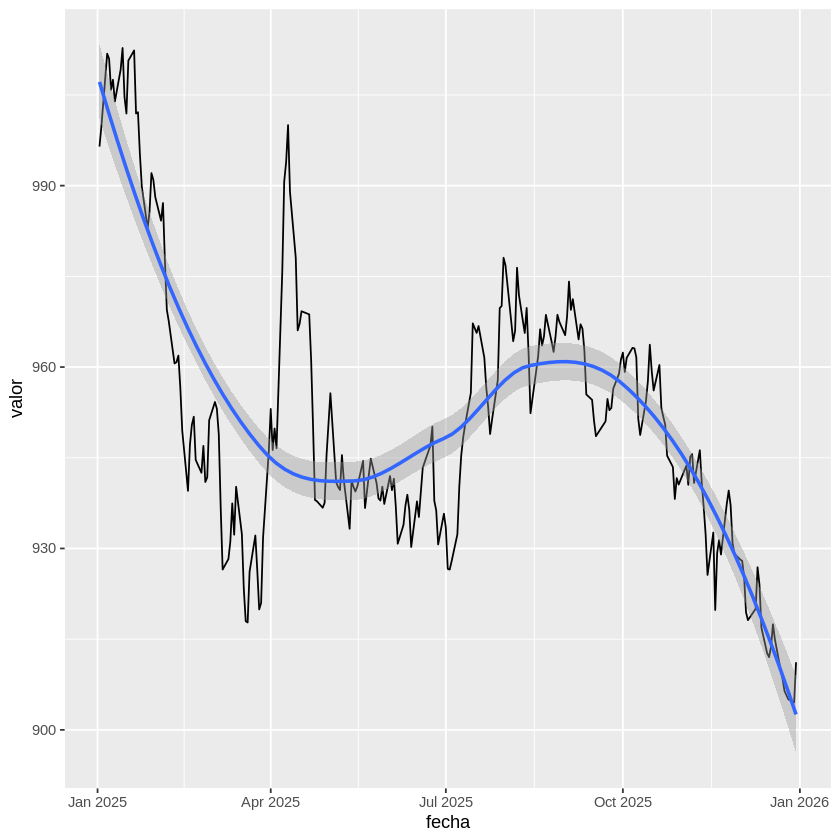

In [39]:
dolar_2025 %>%
  mutate(fecha = as.Date(fecha)) %>%
  ggplot() +
  aes(x = fecha , y = valor) +
  geom_line() +
  geom_smooth()

# IV. Otros parámetros visuales
## IV.1 Etiquetas
Con la capa llamada `labs()`, podemos modificar los nombres de los ejes, títulos, subtítulos y leyenda.




In [40]:
## Ejemplo, consideramos incluir etiquetas y cortes en el eje de tiempo
g1 <- dolar_2025 %>%
  mutate(fecha = as.Date(fecha)) %>%
  ggplot() +
  aes(x = fecha , y = valor) +
  geom_line(col = "red")

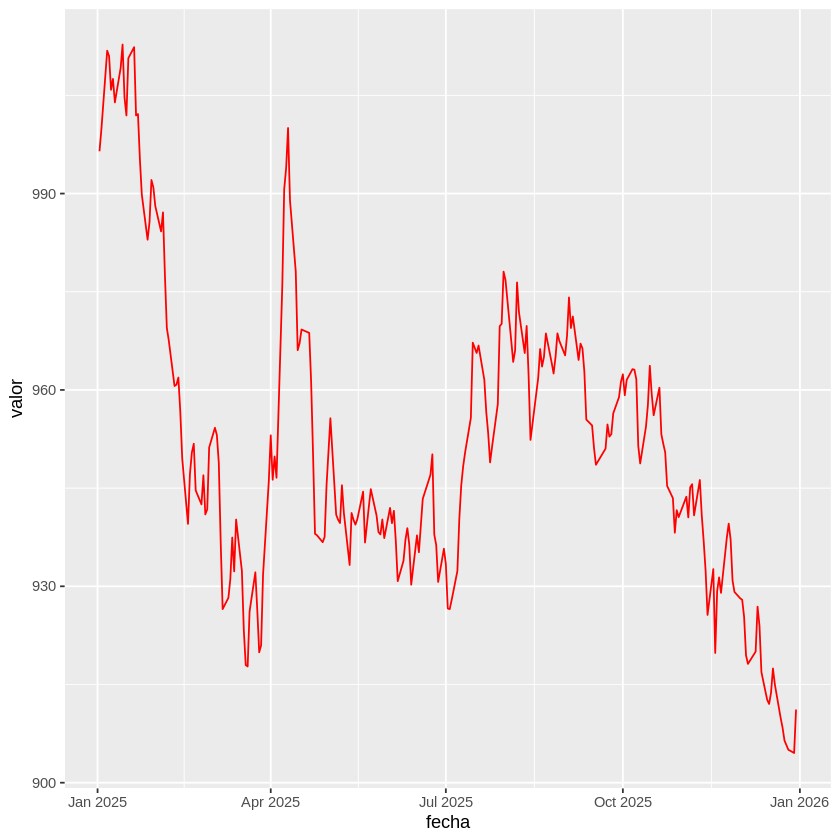

In [41]:
g1

In [42]:
 g2 <- g1 +
  geom_smooth() +
  labs(x = "Fecha de observación del dólar",
       y = "Dólar Observado",
       title = "Serie dólar observado",
       subtitle = "Año 2025",
       caption = "Fuente: https://mindicador.cl/") +
  scale_x_date(date_breaks = "1 month",  date_labels = "%b %y")

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


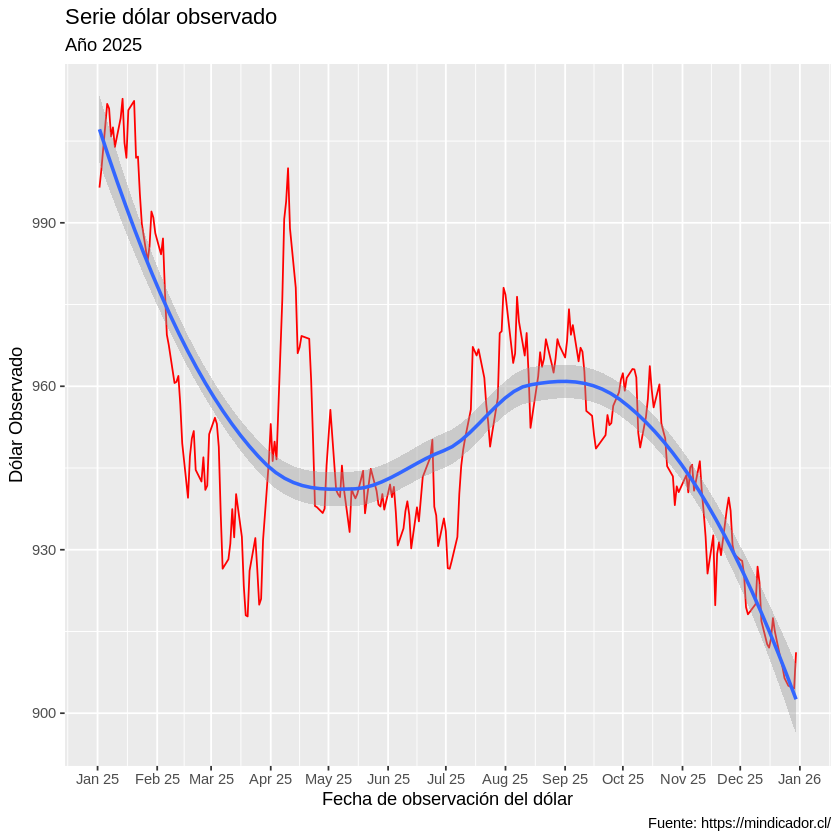

In [43]:
g2

## IV.2 Ejes y escala
Existen diversas funciones que nos peritirán modificar parámetros visuales de los ejes, en función del tipo de dato que estos representen. Algunos de los más usuales son los siguientes
 * `scale_x_date()`, `scale_y_date()`
 * `scale_x_continuous()`, `scale_y_continuous()`
 * `scale_x_discrete()`, `scale_y_discrete()`
 * `scale_x_log10()`, `scale_y_log10()`

En la documentación pueden buscar las demmás opcione mediante el prefijo _scale_

# Guardar un gráfico en el directorio local
Podemos guardar nuestros gráficos en un  directorio local con funciones propias de ggplot2.
```
ggsave(
  filename,
  plot = last_plot(),
  device = NULL,
  path = NULL,
  scale = 1,
  width = NA,
  height = NA,
  units = c("in", "cm", "mm", "px"),
  dpi = 300,
  limitsize = TRUE,
  bg = NULL,
  create.dir = FALSE,
  ...
)
```

In [ ]:
ggsave(
  filename = "dolar_2025.jpg",
  plot = g2
)

Saving 6.67 x 6.67 in image
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


# Serie histórica
Se requiere información del dolar observado desde el 2006 a la fecha (2026-05-26)

## Ciclo `for()`
```
for(t in 1:N){

  ....
}
```

In [44]:
# Ej: Imprimir en consola "día-x" donde x va desde 1 hasta 20.

for(x in 1:20){
  #instrucción (acá dependerá de lo que se quiera realizar)
  print(paste("día",x, sep = "-"))
}





[1] "día-1"
[1] "día-2"
[1] "día-3"
[1] "día-4"
[1] "día-5"
[1] "día-6"
[1] "día-7"
[1] "día-8"
[1] "día-9"
[1] "día-10"
[1] "día-11"
[1] "día-12"
[1] "día-13"
[1] "día-14"
[1] "día-15"
[1] "día-16"
[1] "día-17"
[1] "día-18"
[1] "día-19"
[1] "día-20"


In [46]:
serie_hist_dolar <- data.frame()
serie_hist_dolar

<0 x 0 matrix>

In [55]:
aux <- data.frame(fecha = 3, valor = 300)
aux

fecha,valor
<dbl>,<dbl>
3,300


In [56]:
serie_hist_dolar <- rbind(serie_hist_dolar,aux)

In [57]:
serie_hist_dolar

fecha,valor
<dbl>,<dbl>
1,23
2,30
3,300


In [59]:
url_base <-"https://mindicador.cl"

serie_hist_dolar <- data.frame()

for(anio in 2006:2026){
  print(paste("procesando año: ",anio))
  consulta <- GET(url_base,path = paste0("/api/dolar/",anio) )
  text <- content(consulta, as = "text")
  content <- fromJSON(text)
  serie_dolar <- content$serie
  serie_hist_dolar <- rbind(serie_hist_dolar,serie_dolar)

}



[1] "procesando año:  2006"
[1] "procesando año:  2007"
[1] "procesando año:  2008"
[1] "procesando año:  2009"
[1] "procesando año:  2010"
[1] "procesando año:  2011"
[1] "procesando año:  2012"
[1] "procesando año:  2013"
[1] "procesando año:  2014"
[1] "procesando año:  2015"
[1] "procesando año:  2016"
[1] "procesando año:  2017"
[1] "procesando año:  2018"
[1] "procesando año:  2019"
[1] "procesando año:  2020"
[1] "procesando año:  2021"
[1] "procesando año:  2022"
[1] "procesando año:  2023"
[1] "procesando año:  2024"
[1] "procesando año:  2025"
[1] "procesando año:  2026"


In [60]:
summary(serie_hist_dolar)

       fecha          valor       
 Length   :5080   Min.   : 431.2  
 N.unique :5079   1st Qu.: 524.1  
 N.blank  :   0   Median : 641.1  
 Min.nchar:  24   Mean   : 662.6  
 Max.nchar:  24   3rd Qu.: 790.1  
                  Max.   :1043.0  

In [62]:
head(serie_hist_dolar)
tail(serie_hist_dolar)

,fecha,valor
,<chr>,<dbl>
1,2006-12-29T03:00:00.000Z,534.43
2,2006-12-28T03:00:00.000Z,533.87
3,2006-12-27T03:00:00.000Z,532.69
4,2006-12-26T03:00:00.000Z,530.47
5,2006-12-22T03:00:00.000Z,528.52
6,2006-12-21T03:00:00.000Z,526.91


,fecha,valor
,<chr>,<dbl>
5075,2026-01-09T03:00:00.000Z,896.89
5076,2026-01-08T03:00:00.000Z,895.33
5077,2026-01-07T03:00:00.000Z,896.82
5078,2026-01-06T03:00:00.000Z,905.14
5079,2026-01-05T03:00:00.000Z,901.55
5080,2026-01-02T03:00:00.000Z,907.13


In [63]:
serie_hist_dolar <- serie_hist_dolar %>%
  mutate(fecha = as.Date(fecha)) %>%
  arrange(desc(fecha))

In [64]:
head(serie_hist_dolar)

,fecha,valor
,<date>,<dbl>
1,2026-05-26,893.25
2,2026-05-25,899.86
3,2026-05-22,899.68
4,2026-05-20,907.51
5,2026-05-19,901.59
6,2026-05-18,906.68


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


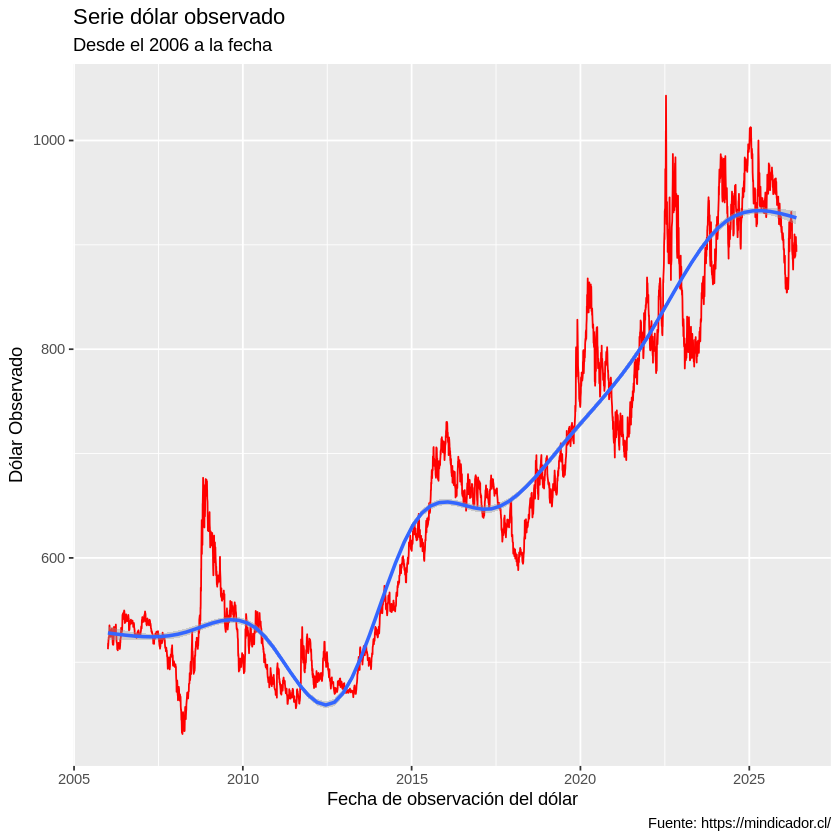

In [66]:
serie_hist_dolar %>%
  ggplot() +
  aes(x = fecha , y = valor) +
  geom_line(col = "red")+
  geom_smooth() +
  labs(x = "Fecha de observación del dólar",
       y = "Dólar Observado",
       title = "Serie dólar observado",
       subtitle = "Desde el 2006 a la fecha",
       caption = "Fuente: https://mindicador.cl/")